In [97]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd


In [98]:
df = pd.read_excel(r'C:\Programming\ETH\SS26\ISQT26\market_autoencoder\data.xlsx',
                   sheet_name='Raw Data', engine='openpyxl', header=3)
df = df.rename(columns={df.columns[0]: 'Date'})
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date']).set_index('Date')
df = df.loc[:, ~df.columns.astype(str).str.startswith('Unnamed')]   # drop blank spacer column

C:\Users\trist\AppData\Local\Temp\ipykernel_9976\4135330000.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


In [99]:
df.head(100)

,US-DS Market - PER,US GVT EVAL BMK BID YLD 10Y - RED. YIELD,US CPI - ALL URBAN: ALL ITEMS SADJ,TOTMKUS(PI)/TOTMKUS(PE),US GVT EVAL BMK BID YLD 3M - RED. YIELD,12M FWD E,Real Yield,Steepness
Date,,,,,,,,
1973-01-31,23.6,6.54,42.7,4.14,5.68,NaN,NaN,NaN
1973-02-28,22.8,6.64,43,4.14,5.85,NaN,NaN,NaN
1973-03-30,22.7,6.73,43.4,4.15,6.4,NaN,NaN,NaN
1973-04-30,21.6,6.7,43.7,4.17,6.23,NaN,NaN,NaN
1973-05-31,20.7,6.93,43.9,4.29,6.92,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
1980-12-31,8.6,12.43,86.4,11.38,14.3,NaN,NaN,NaN
1981-01-30,8.3,12.68,87.2,11.39,14.59,NaN,NaN,NaN
1981-02-27,8.5,13.43,88,11.41,14.22,NaN,NaN,NaN


In [100]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 627 entries, 1973-01-31 to 2025-03-31
Data columns (total 8 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   US-DS Market - PER                        627 non-null    object 
 1   US GVT EVAL BMK BID YLD 10Y - RED. YIELD  627 non-null    object 
 2   US CPI - ALL URBAN: ALL ITEMS SADJ        627 non-null    object 
 3   TOTMKUS(PI)/TOTMKUS(PE)                   627 non-null    object 
 4   US GVT EVAL BMK BID YLD 3M - RED. YIELD   627 non-null    object 
 5   12M FWD E                                 495 non-null    float64
 6   Real Yield                                507 non-null    float64
 7   Steepness                                 507 non-null    float64
dtypes: float64(3), object(5)
memory usage: 44.1+ KB


In [215]:
# --- clean: object cols -> numeric, then drop all rows with any NaN ---
for c in df.columns:
    if df[c].dtype == object:
        df[c] = df[c].astype(str).str.replace(",", "", regex=False).str.strip()
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.dropna()

X = df.values.astype(np.float32)
d = X.shape[1]
print(X.shape)   # rows left after the leading NaN block is gone

(495, 8)


In [216]:
# --- pick the input set ---
drop = ["Real Yield", "Steepness"]          # -> 6 raw inputs; use ["Real Yield"] for 7
cols = [c for c in df.columns if c not in drop]
X = df[cols].values.astype(np.float32)
d = X.shape[1]
print(cols, "| d =", d)

['US-DS Market - PER', 'US GVT EVAL BMK BID YLD 10Y - RED. YIELD', 'US CPI - ALL URBAN: ALL ITEMS SADJ', 'TOTMKUS(PI)/TOTMKUS(PE)', 'US GVT EVAL BMK BID YLD 3M - RED. YIELD', '12M FWD E'] | d = 6


In [217]:
dates = df.index

In [218]:
from sklearn.preprocessing import MinMaxScaler

X_train, X_test = X[:-12], X[-12:]

scaler = MinMaxScaler(feature_range=(-1, 1)).fit(X_train)
Xtr = torch.tensor(scaler.transform(X_train))
Xte = torch.tensor(scaler.transform(X_test))
print(Xtr.shape, Xte.shape)

torch.Size([483, 6]) torch.Size([12, 6])


In [265]:
torch.manual_seed(0)

# --- model: d -> 3 -> d, tanh ---
model = torch.nn.Sequential(
    torch.nn.Linear(d, 3), torch.nn.Tanh(),
    torch.nn.Linear(3, d), torch.nn.Tanh(),

)
opt = torch.optim.Adam(model.parameters(), lr=1e-2, weight_decay=1e-5)
loss_fn = torch.nn.MSELoss()

In [266]:
# --- train ---
for epoch in range(1, 5001):
    opt.zero_grad()
    loss = loss_fn(model(Xtr), Xtr)
    loss.backward()
    opt.step()
    if epoch % 200 == 0:
        with torch.no_grad():
            te = loss_fn(model(Xte), Xte).item()
        print(f"epoch {epoch:4d} | train {loss.item():.5f} | test {te:.5f}")

epoch  200 | train 0.02561 | test 0.21906
epoch  400 | train 0.01268 | test 0.19550
epoch  600 | train 0.01174 | test 0.15483
epoch  800 | train 0.01138 | test 0.13101
epoch 1000 | train 0.01117 | test 0.12180
epoch 1200 | train 0.01102 | test 0.11669
epoch 1400 | train 0.01089 | test 0.11301
epoch 1600 | train 0.01077 | test 0.11001
epoch 1800 | train 0.01064 | test 0.10747
epoch 2000 | train 0.01050 | test 0.10547
epoch 2200 | train 0.01035 | test 0.10420
epoch 2400 | train 0.01021 | test 0.10346
epoch 2600 | train 0.01009 | test 0.10297
epoch 2800 | train 0.01000 | test 0.10262
epoch 3000 | train 0.00993 | test 0.10234
epoch 3200 | train 0.00990 | test 0.10225
epoch 3400 | train 0.00982 | test 0.10191
epoch 3600 | train 0.00978 | test 0.10169
epoch 3800 | train 0.00974 | test 0.10146
epoch 4000 | train 0.00971 | test 0.10118
epoch 4200 | train 0.00968 | test 0.10101
epoch 4400 | train 0.00965 | test 0.10081
epoch 4600 | train 0.00963 | test 0.10058
epoch 4800 | train 0.00962 | test 

In [267]:
# --- final eval ---
with torch.no_grad():
    print(f"train MSE {loss_fn(model(Xtr), Xtr).item():.5f}")
    print(f"test  MSE {loss_fn(model(Xte), Xte).item():.5f}")

train MSE 0.00958
test  MSE 0.10021


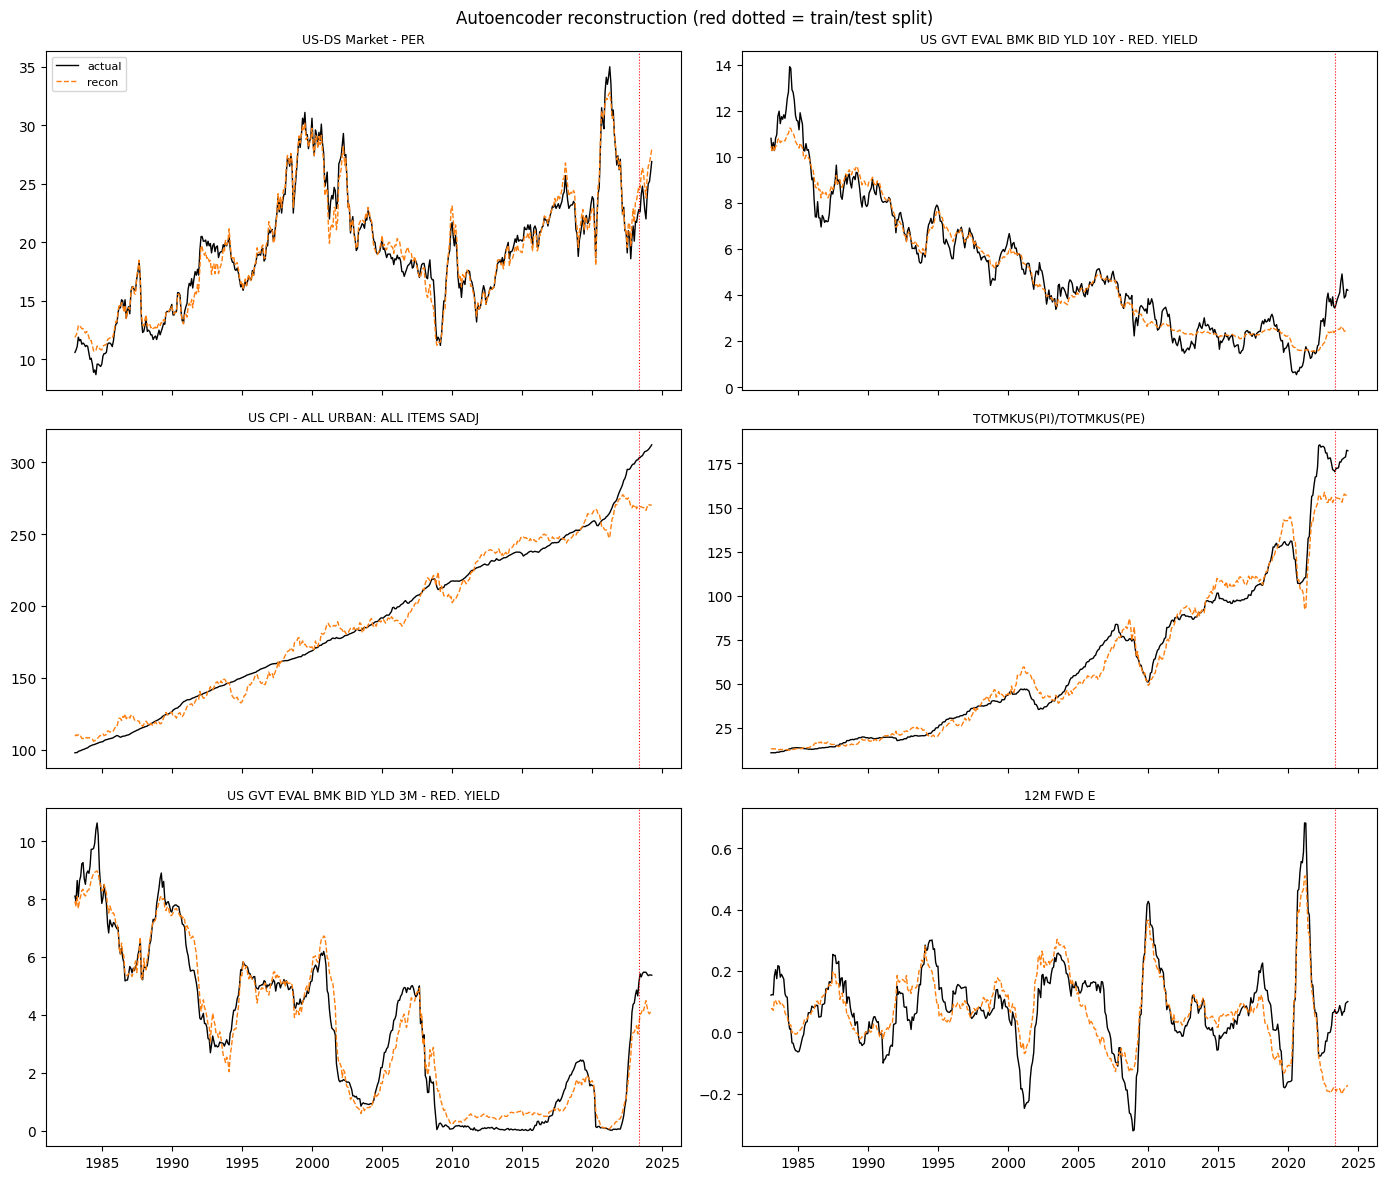

In [268]:
# --- reconstruct all, back in original units ---
with torch.no_grad():
    Xtr_hat = scaler.inverse_transform(model(Xtr).numpy())
    Xte_hat = scaler.inverse_transform(model(Xte).numpy())

recon = np.vstack([Xtr_hat, Xte_hat])    # aligned with df row order
split = len(Xtr)
dates, cols = df.index, df.columns

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
for i, ax in enumerate(axes.ravel()):
    ax.plot(dates, X[:, i], color="black", lw=1, label="actual")
    ax.plot(dates, recon[:, i], color="C1", lw=1, ls="--", label="recon")
    ax.axvline(dates[split], color="red", lw=0.8, ls=":")
    ax.set_title(cols[i], fontsize=9)
    if i == 0:
        ax.legend(fontsize=8)
fig.suptitle("Autoencoder reconstruction (red dotted = train/test split)")
fig.tight_layout()
plt.show()

In [269]:
# --- latents (encoder = first two layers) + correlation with each feature ---
with torch.no_grad():
    Z = model[:2](torch.tensor(scaler.transform(X))).numpy()   # (N, 4)
k = Z.shape[1]

Xc = (X - X.mean(0)) / X.std(0)
Zc = (Z - Z.mean(0)) / Z.std(0)
corr = Zc.T @ Xc / len(X)                       # (k, d)

cols = [c for c in df.columns if c not in drop]   # rebuild the 6-col list locally
corr_df = pd.DataFrame(corr, index=[f"z{j+1}" for j in range(k)], columns=cols)
best = corr_df.abs().idxmax(axis=1)             # feature each latent tracks most
display(corr_df.round(2))
print(best)

,US-DS Market - PER,US GVT EVAL BMK BID YLD 10Y - RED. YIELD,US CPI - ALL URBAN: ALL ITEMS SADJ,TOTMKUS(PI)/TOTMKUS(PE),US GVT EVAL BMK BID YLD 3M - RED. YIELD,12M FWD E
z1,-0.40,0.85,-0.68,-0.53,0.95,-0.36
z2,0.85,-0.86,0.88,0.80,-0.68,0.11
z3,-0.10,0.80,-0.87,-0.85,0.71,0.31


z1    US GVT EVAL BMK BID YLD 3M - RED. YIELD
z2         US CPI - ALL URBAN: ALL ITEMS SADJ
z3         US CPI - ALL URBAN: ALL ITEMS SADJ
dtype: str


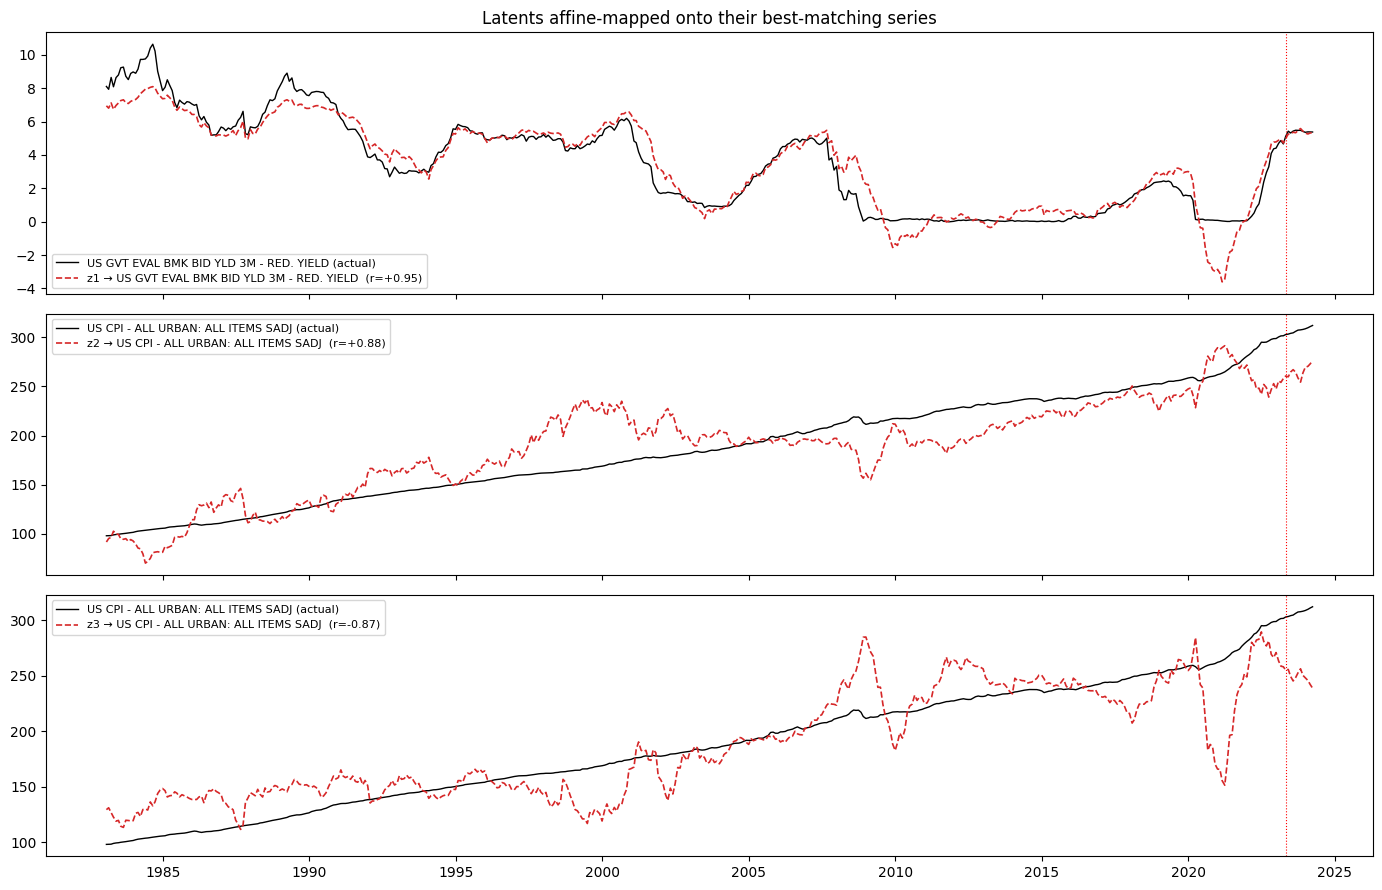

In [270]:
# --- map each latent onto its best-matching series' real units, overlay ---
fig, axes = plt.subplots(k, 1, figsize=(14, 3*k), sharex=True)
for j, ax in enumerate(np.atleast_1d(axes)):
    feat = best.iloc[j]
    fi = list(cols).index(feat)
    a, b = np.polyfit(Z[:, j], X[:, fi], 1)     # affine map to feature units
    z_scaled = a * Z[:, j] + b
    ax.plot(dates, X[:, fi], color="black", lw=1, label=f"{feat} (actual)")
    ax.plot(dates, z_scaled, color="C3", lw=1.2, ls="--",
            label=f"z{j+1} → {feat}  (r={corr_df.iloc[j, fi]:+.2f})")
    ax.axvline(dates[split], color="red", lw=0.8, ls=":")
    ax.legend(fontsize=8, loc="best")
axes[0].set_title("Latents affine-mapped onto their best-matching series")
fig.tight_layout()
plt.show()

latent Δ  train MAE 0.0009 RMSE 0.0012 | test MAE 0.0013 RMSE 0.0016
pca-3  Δ  train MAE 0.0014 RMSE 0.0019 | test MAE 0.0016 RMSE 0.0020
raw-6  Δ  train MAE 0.0002 RMSE 0.0003 | test MAE 0.0001 RMSE 0.0002
zero-Δ baseline test RMSE 0.0029
PCA explained var (train): [0.751 0.11  0.082]  sum=0.943


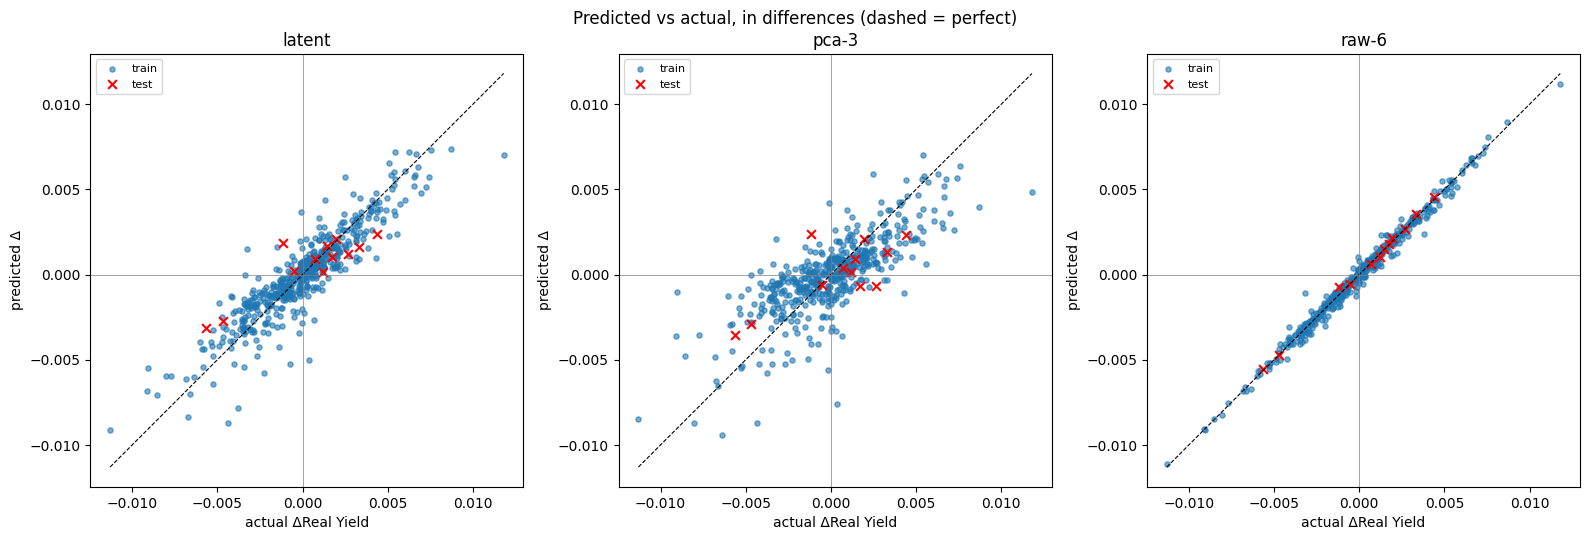

In [271]:
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA

y = df["Real Yield"].values.astype(np.float32)

with torch.no_grad():
    Z = model[:2](torch.tensor(scaler.transform(X))).numpy()      # AE latent (nonlinear, 2D)
pca = PCA(n_components=3).fit(scaler.transform(X[:split]))         # linear 2D, train only
P = pca.transform(scaler.transform(X))                            # (N,2) PC scores

# --- difference everything (in and out) ---
dy = np.diff(y); dZ = np.diff(Z, axis=0); dP = np.diff(P, axis=0); dX = np.diff(X, axis=0)
s  = split - 1
dytr, dyte = dy[:s], dy[s:]

reg  = LinearRegression().fit(dZ[:s], dytr); pred = reg.predict(dZ)   # latent
regP = LinearRegression().fit(dP[:s], dytr); pp   = regP.predict(dP)  # pca
base = LinearRegression().fit(dX[:s], dytr); pb   = base.predict(dX)  # raw-6

mae  = lambda a, p: np.mean(np.abs(np.asarray(a, float) - p))
rmse = lambda a, p: np.sqrt(np.mean((np.asarray(a, float) - p)**2))
for name, p in [("latent", pred), ("pca-3", pp), ("raw-6", pb)]:
    print(f"{name:6s} Δ  train MAE {mae(dytr, p[:s]):.4f} RMSE {rmse(dytr, p[:s]):.4f}"
          f" | test MAE {mae(dyte, p[s:]):.4f} RMSE {rmse(dyte, p[s:]):.4f}")
print(f"zero-Δ baseline test RMSE {rmse(dyte, np.zeros_like(dyte)):.4f}")
print(f"PCA explained var (train): {pca.explained_variance_ratio_.round(3)}  sum={pca.explained_variance_ratio_.sum():.3f}")

# --- predicted Δ vs actual Δ ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5.3))
for ax, name, p in [(axes[0], "latent", pred), (axes[1], "pca-3", pp), (axes[2], "raw-6", pb)]:
    ax.scatter(dytr, p[:s], s=14, color="C0", alpha=0.6, label="train")
    ax.scatter(dyte, p[s:], s=40, color="red", marker="x", label="test")
    lo = min(dy.min(), p.min()); hi = max(dy.max(), p.max())
    ax.plot([lo, hi], [lo, hi], color="black", lw=0.8, ls="--")
    ax.axhline(0, color="grey", lw=0.5); ax.axvline(0, color="grey", lw=0.5)
    ax.set_xlabel("actual ΔReal Yield"); ax.set_ylabel("predicted Δ")
    ax.set_title(name); ax.legend(fontsize=8); ax.set_aspect("equal")
fig.suptitle("Predicted vs actual, in differences (dashed = perfect)")
fig.tight_layout(); plt.show()

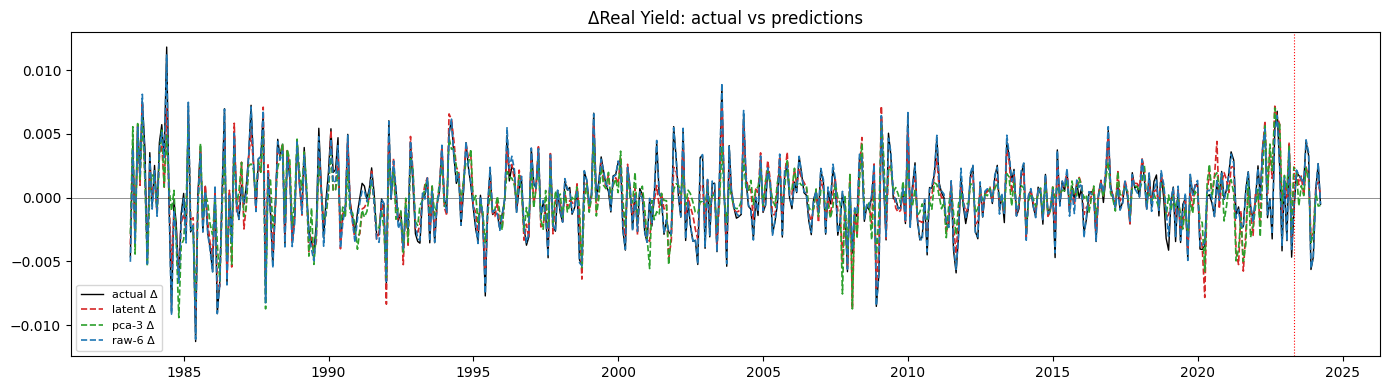

In [272]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.axhline(0, color="grey", lw=0.6)
ax.plot(dates[1:], dy,   color="black", lw=1,   label="actual Δ")
ax.plot(dates[1:], pred, color="C3", lw=1.2, ls="--", label="latent Δ")
ax.plot(dates[1:], pp,   color="C2", lw=1.2, ls="--", label="pca-3 Δ")
ax.plot(dates[1:], pb,   color="C0", lw=1.2, ls="--", label="raw-6 Δ")
ax.axvline(dates[split], color="red", lw=0.8, ls=":")
ax.legend(fontsize=8); ax.set_title("ΔReal Yield: actual vs predictions")
fig.tight_layout(); plt.show()

latent  Δ train MAE 0.0009 RMSE 0.0012
pca-3   Δ train MAE 0.0014 RMSE 0.0019
raw-6   Δ train MAE 0.0002 RMSE 0.0003
zero-Δ  train RMSE 0.0029


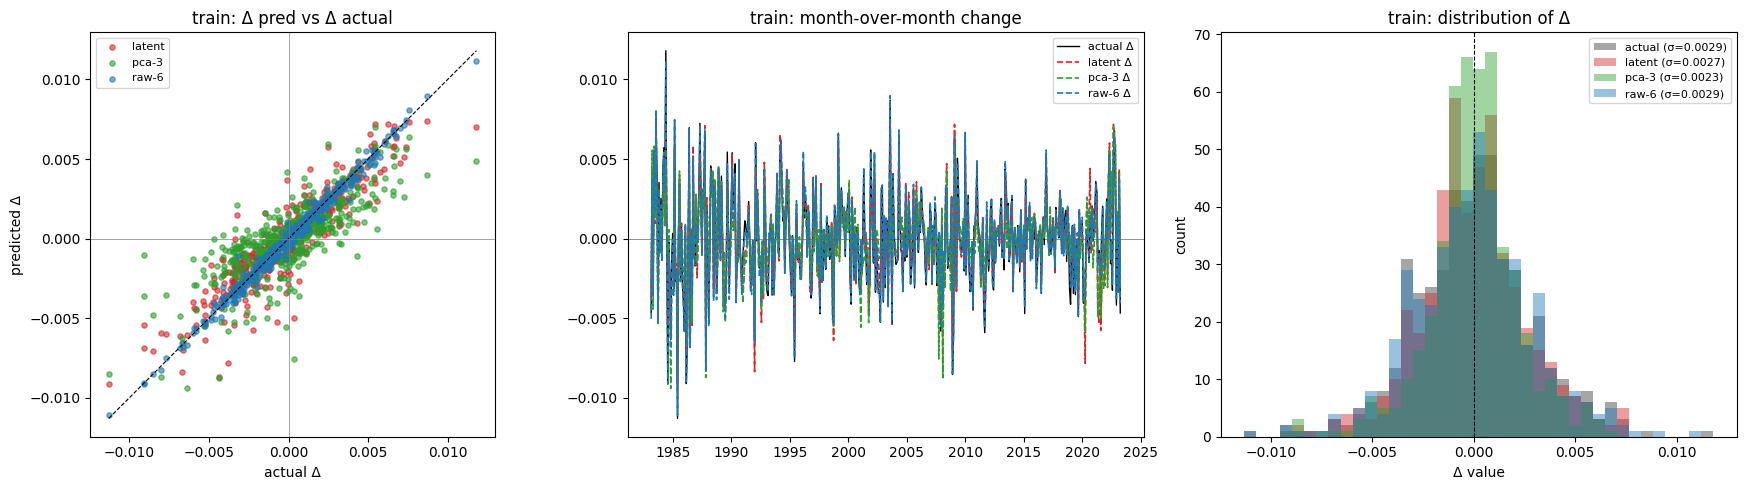

In [273]:
s = split - 1
dyt, dpt, dppt, dbt, ddt = dytr, pred[:s], pp[:s], pb[:s], dates[1:split]

print(f"latent  Δ train MAE {mae(dyt, dpt):.4f} RMSE {rmse(dyt, dpt):.4f}")
print(f"pca-3   Δ train MAE {mae(dyt, dppt):.4f} RMSE {rmse(dyt, dppt):.4f}")
print(f"raw-6   Δ train MAE {mae(dyt, dbt):.4f} RMSE {rmse(dyt, dbt):.4f}")
print(f"zero-Δ  train RMSE {rmse(dyt, np.zeros_like(dyt)):.4f}")

fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(18, 5))

# scatter: predicted Δ vs actual Δ
a1.scatter(dyt, dpt,  s=14, color="C3", alpha=0.6, label="latent")
a1.scatter(dyt, dppt, s=14, color="C2", alpha=0.6, label="pca-3")
a1.scatter(dyt, dbt,  s=14, color="C0", alpha=0.6, label="raw-6")
lo, hi = dyt.min(), dyt.max()
a1.plot([lo, hi], [lo, hi], color="black", lw=0.8, ls="--")
a1.axhline(0, color="grey", lw=0.5); a1.axvline(0, color="grey", lw=0.5)
a1.set_xlabel("actual Δ"); a1.set_ylabel("predicted Δ")
a1.set_title("train: Δ pred vs Δ actual"); a1.legend(fontsize=8); a1.set_aspect("equal")

# time series of changes
a2.axhline(0, color="grey", lw=0.6)
a2.plot(ddt, dyt,  color="black", lw=1, label="actual Δ")
a2.plot(ddt, dpt,  color="C3", lw=1.2, ls="--", label="latent Δ")
a2.plot(ddt, dppt, color="C2", lw=1.2, ls="--", label="pca-3 Δ")
a2.plot(ddt, dbt,  color="C0", lw=1.2, ls="--", label="raw-6 Δ")
a2.set_title("train: month-over-month change"); a2.legend(fontsize=8)

# histograms of the actual Δ values (predicted vs actual distribution)
bins = np.linspace(dyt.min(), dyt.max(), 40)
a3.hist(dyt,  bins=bins, color="black", alpha=0.35, label=f"actual (σ={dyt.std():.4f})")
a3.hist(dpt,  bins=bins, color="C3",    alpha=0.45, label=f"latent (σ={dpt.std():.4f})")
a3.hist(dppt, bins=bins, color="C2",    alpha=0.45, label=f"pca-3 (σ={dppt.std():.4f})")
a3.hist(dbt,  bins=bins, color="C0",    alpha=0.45, label=f"raw-6 (σ={dbt.std():.4f})")
a3.axvline(0, color="black", lw=0.8, ls="--")
a3.set_xlabel("Δ value"); a3.set_ylabel("count")
a3.set_title("train: distribution of Δ"); a3.legend(fontsize=8)

fig.tight_layout(); plt.show()

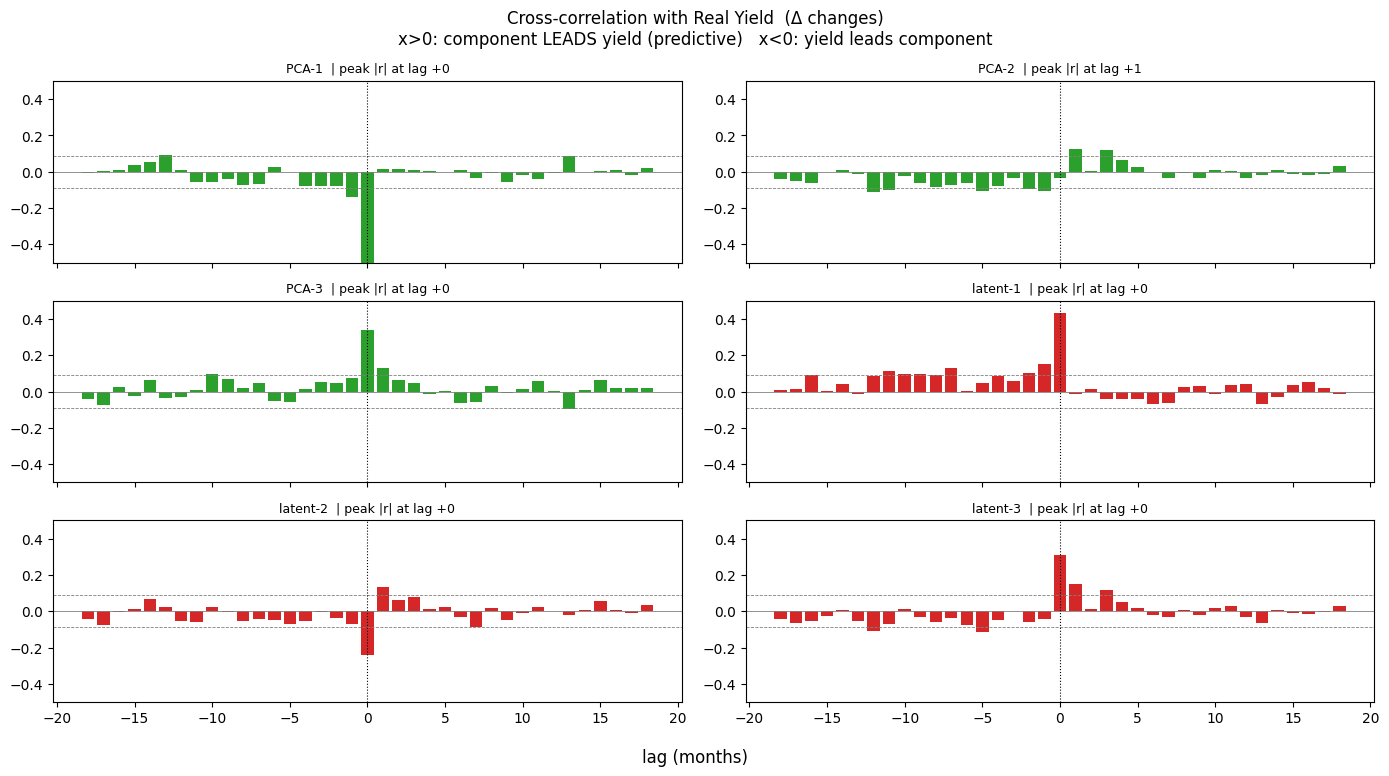

In [275]:
def ccf_lags(a, b, lags):
    # r(k) = corr(a_{t}, b_{t+k}); k>0 means a LEADS b by k
    a = np.asarray(a, float); b = np.asarray(b, float)
    out = []
    for k in lags:
        if k >= 0:
            x, z = a[:len(a)-k], b[k:]
        else:
            x, z = a[-k:], b[:len(b)+k]
        out.append(np.corrcoef(x, z)[0, 1])
    return np.array(out)

LAGS = np.arange(-18, 19)
USE_CHANGES = True                              # True: Δ (honest lead-lag); False: levels
yv = np.diff(y) if USE_CHANGES else y
Pv = np.diff(P, axis=0) if USE_CHANGES else P
Zv = np.diff(Z, axis=0) if USE_CHANGES else Z
ci = 1.96 / np.sqrt(len(yv))

comps  = [(f"PCA-{j+1}", Pv[:, j], "C2") for j in range(Pv.shape[1])]
comps += [(f"latent-{j+1}", Zv[:, j], "C3") for j in range(Zv.shape[1])]

n = len(comps); ncol = 2; nrow = int(np.ceil(n/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(14, 2.6*nrow), sharex=True)
axes = axes.ravel()
for ax, (name, v, c) in zip(axes, comps):
    r = ccf_lags(v, yv, LAGS)
    ax.bar(LAGS, r, color=c, width=0.8)
    ax.axhline(0, color="grey", lw=0.6)
    ax.axhline( ci, color="grey", lw=0.6, ls="--"); ax.axhline(-ci, color="grey", lw=0.6, ls="--")
    ax.axvline(0, color="black", lw=0.8, ls=":")
    kbest = LAGS[np.argmax(np.abs(r))]
    ax.set_title(f"{name}  | peak |r| at lag {kbest:+d}", fontsize=9)
    ax.set_ylim(-1.0 if not USE_CHANGES else -0.5, 1.05 if not USE_CHANGES else 0.5)
for ax in axes[n:]: ax.set_visible(False)
fig.suptitle(f"Cross-correlation with Real Yield  ({'Δ changes' if USE_CHANGES else 'levels'})\n"
             "x>0: component LEADS yield (predictive)   x<0: yield leads component")
fig.supxlabel("lag (months)"); fig.tight_layout(); plt.show()

walk-forward grid:   0%|          | 0/1908 [00:00<?, ?it/s]

,window,arm,pts,sharpe,t,hit,z,ic,turn_pa,maxdd
0,96,dy-only,398,-0.192,-1.106,0.497,-0.100,-0.010,7.387,0.114
1,96,PCA-d,398,-0.198,-1.141,0.523,0.902,0.124,10.764,0.098
2,96,latent-d,398,-0.185,-1.063,0.503,0.100,0.043,10.523,0.109
3,96,buy&hold,398,0.074,0.429,0.495,-0.201,NaN,0.000,0.033
4,128,dy-only,366,-0.078,-0.430,0.508,0.314,-0.000,7.705,0.068
5,128,PCA-d,366,0.120,0.664,0.560,2.300,0.151,10.721,0.042
6,128,latent-d,366,0.066,0.363,0.538,1.464,0.078,10.459,0.047
7,128,buy&hold,366,0.009,0.052,0.489,-0.418,NaN,0.000,0.033
8,160,dy-only,334,-0.094,-0.498,0.509,0.328,-0.010,6.359,0.065
9,160,PCA-d,334,0.037,0.196,0.548,1.751,0.166,10.383,0.050


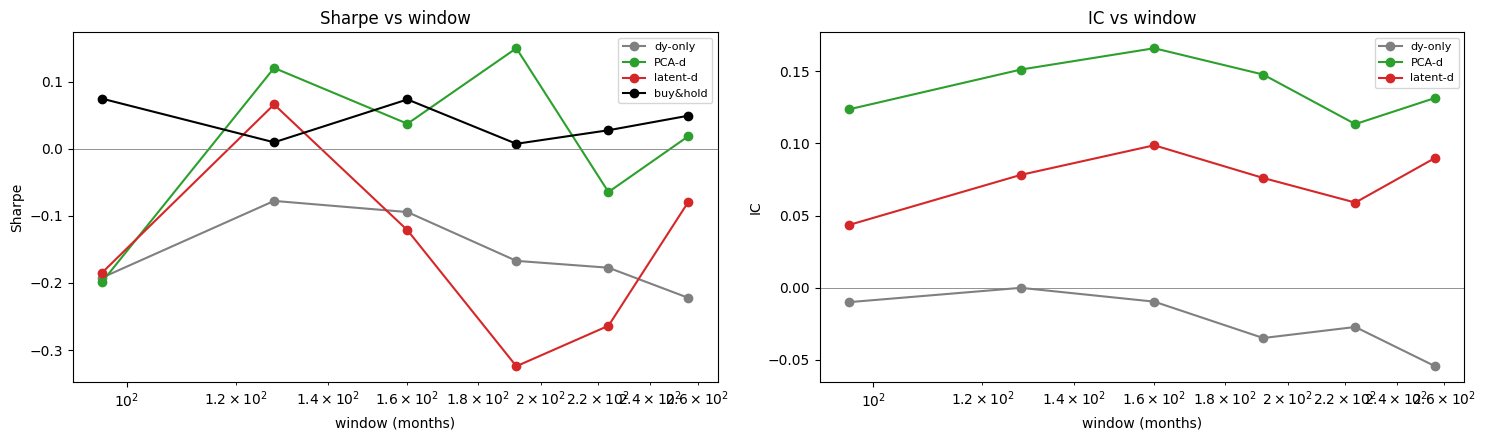

In [301]:
import warnings; warnings.filterwarnings("ignore")
import torch
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from tqdm.auto import tqdm

GRID      = [96, 128, 160, 192, 224, 256]
BN        = 3
REFIT_AE  = True
AE_EPOCHS = 500
USE_LEVEL = False
COST      = 0.0002           # set 0.0002 / 0.0005 to stress

N = len(y)
targ_full = np.r_[np.diff(y), np.nan]

def lin_pred(F, t, f_now): return LinearRegression().fit(F, t).predict(f_now)[0]

def diff_design(comp, yw):
    dC, dyw = np.diff(comp, axis=0), np.diff(yw)
    cols_tr = [dC[:-1], dyw[:-1].reshape(-1, 1)]; cols_now = [dC[-1], [dyw[-1]]]
    if USE_LEVEL:
        cols_tr.append(yw[1:-1].reshape(-1, 1)); cols_now.append([yw[-1]])
    return np.column_stack(cols_tr), dyw[1:], np.concatenate(cols_now).reshape(1, -1)

def metrics(pred, actual, cost=COST):
    m = ~np.isnan(pred); p, a = np.sign(pred[m]), actual[m]; nn = m.sum()
    turn = np.abs(np.diff(np.r_[0, p])); net = p * a - cost * turn
    sd = net.std(); cum = np.cumsum(net)
    return dict(pts=nn, sharpe=net.mean()/sd*np.sqrt(12) if sd>0 else 0,
                t=net.mean()/(sd/np.sqrt(nn)) if sd>0 else 0,
                hit=np.mean(p == np.sign(a)), z=(np.mean(p==np.sign(a))-0.5)/np.sqrt(0.25/nn),
                ic=np.corrcoef(pred[m], a)[0,1], turn_pa=turn.mean()*12,
                maxdd=(np.maximum.accumulate(cum)-cum).max())

valid = [W for W in GRID if W < N - 2]
bar = tqdm(total=sum((N-1)-W for W in valid), desc="walk-forward grid")
rows = []
for W in valid:
    oos = {k: np.full(N, np.nan) for k in ["dy-only", "PCA-d", "latent-d"]}
    for t in range(W, N - 1):
        idx = slice(t - W + 1, t + 1); Xw, yw = X[idx], y[idx]
        sc = MinMaxScaler((-1, 1)).fit(Xw); Xs = sc.transform(Xw)
        nbn = min(BN, Xw.shape[1], Xw.shape[0] - 1)            # clamp components for tiny windows
        Pw = PCA(n_components=nbn).fit(Xs).transform(Xs)
        dyw = np.diff(yw)
        if USE_LEVEL:
            Fy = np.column_stack([dyw[:-1], yw[1:-1]]); fy_now = np.r_[dyw[-1], yw[-1]].reshape(1,-1)
        else:
            Fy = dyw[:-1].reshape(-1, 1); fy_now = np.array([[dyw[-1]]])
        oos["dy-only"][t] = lin_pred(Fy, dyw[1:], fy_now)
        Fp, tp, fp = diff_design(Pw, yw); oos["PCA-d"][t] = lin_pred(Fp, tp, fp)
        if REFIT_AE:
            torch.manual_seed(0)
            ae = torch.nn.Sequential(torch.nn.Linear(d, nbn), torch.nn.Tanh(),
                                     torch.nn.Linear(nbn, d), torch.nn.Tanh())
            op = torch.optim.Adam(ae.parameters(), lr=1e-2, weight_decay=1e-5)
            xw = torch.tensor(Xs)
            for _ in range(AE_EPOCHS):
                op.zero_grad(); torch.nn.functional.mse_loss(ae(xw), xw).backward(); op.step()
            with torch.no_grad(): Zw = ae[:2](xw).numpy()
            Fz, tz, fz = diff_design(Zw, yw); oos["latent-d"][t] = lin_pred(Fz, tz, fz)
        bar.update(1)
    arms = ["dy-only", "PCA-d"] + (["latent-d"] if REFIT_AE else [])
    for name in arms:
        r = metrics(oos[name], targ_full); r.update(window=W, arm=name); rows.append(r)
    # buy & hold over this window's OOS span
    m = ~np.isnan(oos["dy-only"]); a = targ_full[m]; bh = -a
    rows.append(dict(window=W, arm="buy&hold", pts=m.sum(),
                     sharpe=bh.mean()/bh.std()*np.sqrt(12), t=bh.mean()/(bh.std()/np.sqrt(m.sum())),
                     hit=np.mean(a<0), z=(np.mean(a<0)-0.5)/np.sqrt(0.25/m.sum()),
                     ic=np.nan, turn_pa=0.0,
                     maxdd=(np.maximum.accumulate(np.cumsum(bh))-np.cumsum(bh)).max()))
bar.close()

tbl = pd.DataFrame(rows)[["window","arm","pts","sharpe","t","hit","z","ic","turn_pa","maxdd"]]
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
display(tbl)

# Sharpe and IC across windows, per arm
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 4.5))
for name, c in [("dy-only","grey"),("PCA-d","C2"),("latent-d","C3"),("buy&hold","black")]:
    sub = tbl[tbl.arm == name]
    if len(sub):
        a1.plot(sub.window, sub.sharpe, "o-", color=c, label=name)
        if name != "buy&hold": a2.plot(sub.window, sub["ic"], "o-", color=c, label=name)
a1.axhline(0, color="grey", lw=0.6); a1.set_xscale("log")
a1.set_xlabel("window (months)"); a1.set_ylabel("Sharpe"); a1.set_title("Sharpe vs window"); a1.legend(fontsize=8)
a2.axhline(0, color="grey", lw=0.6); a2.set_xscale("log")
a2.set_xlabel("window (months)"); a2.set_ylabel("IC"); a2.set_title("IC vs window"); a2.legend(fontsize=8)
fig.tight_layout(); plt.show()

PCA-d, cost=0.0002 (2bp per unit, ~4bp round-trip)


,window,k,sharpe,t,turn_pa,frac_in,net_total,breakeven_bp
0,96,0.000,-0.198,-1.141,10.764,1.000,-0.059,0.359
1,96,0.500,0.231,1.330,3.889,1.000,0.068,7.288
2,96,1.000,0.302,1.736,1.960,1.000,0.089,15.702
3,96,1.500,0.241,1.387,0.814,0.970,0.069,27.740
4,96,2.000,0.069,0.397,0.573,0.970,0.020,12.496
5,128,0.000,0.120,0.664,10.721,1.000,0.033,2.995
6,128,0.500,0.111,0.614,4.164,1.000,0.030,4.375
7,128,1.000,0.067,0.370,2.131,0.997,0.018,4.804
8,128,1.500,0.184,1.015,0.820,0.981,0.049,21.547
9,128,2.000,0.048,0.266,0.557,0.981,0.013,9.542


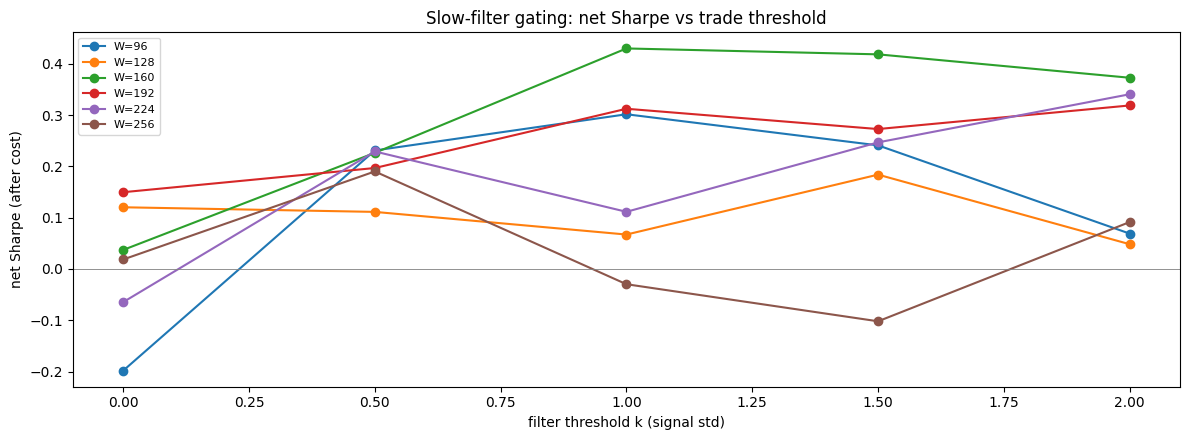

In [302]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

GRID = [96, 128, 160, 192, 224, 256]
BN, COST = 3, 0.0002
K_GRID = [0.0, 0.5, 1.0, 1.5, 2.0]      # filter thresholds (in units of signal std); 0 = no filter
N = len(y); targ_full = np.r_[np.diff(y), np.nan]

def diff_design(comp, yw):
    dC, dyw = np.diff(comp, axis=0), np.diff(yw)
    return (np.column_stack([dC[:-1], dyw[:-1].reshape(-1,1)]), dyw[1:],
            np.r_[dC[-1], dyw[-1]].reshape(1,-1))

# --- 1. fast recompute of prediction series (PCA-d, dy-only); no AE ---
OOS = {}
for W in GRID:
    if W >= N-2: continue
    oP, oY = np.full(N, np.nan), np.full(N, np.nan)
    for t in range(W, N-1):
        Xw, yw = X[t-W+1:t+1], y[t-W+1:t+1]
        Xs = MinMaxScaler((-1,1)).fit_transform(Xw)
        nbn = min(BN, Xw.shape[1], Xw.shape[0]-1)
        Pw = PCA(n_components=nbn).fit(Xs).transform(Xs)
        dyw = np.diff(yw)
        oY[t] = LinearRegression().fit(dyw[:-1].reshape(-1,1), dyw[1:]).predict([[dyw[-1]]])[0]
        Fp, tp, fp = diff_design(Pw, yw)
        oP[t] = LinearRegression().fit(Fp, tp).predict(fp)[0]
    OOS[W] = {"PCA-d": oP, "dy-only": oY}

# --- 2. slow-filter gate: hold position until |signal| crosses k*sigma (stopping-time) ---
def gate(pred, k):
    sig = np.nanstd(pred); pos = np.full_like(pred, np.nan); cur = 0.0
    for i, pi in enumerate(pred):
        if np.isnan(pi): continue
        if   pi >  k*sig: cur = 1.0
        elif pi < -k*sig: cur = -1.0
        pos[i] = cur                      # else hold previous (no trade)
    return pos

def evalp(pred, k, cost=COST):
    pos = gate(pred, k); m = ~np.isnan(pos); p, a = pos[m], targ_full[m]; nn = m.sum()
    turn = np.abs(np.diff(np.r_[0, p])); net = p*a - cost*turn
    gross = p*a; sd = net.std()
    return dict(k=k, sharpe=net.mean()/sd*np.sqrt(12) if sd>0 else 0,
                t=net.mean()/(sd/np.sqrt(nn)) if sd>0 else 0,
                turn_pa=turn.mean()*12, frac_in=np.mean(p!=0),
                net_total=np.cumsum(net)[-1],
                breakeven_bp=1e4*gross.mean()/turn.mean() if turn.mean()>0 else np.nan)

# --- 3. sweep filter strength for PCA-d across windows ---
rows = []
for W in OOS:
    for k in K_GRID:
        r = evalp(OOS[W]["PCA-d"], k); r.update(window=W); rows.append(r)
tbl = pd.DataFrame(rows)[["window","k","sharpe","t","turn_pa","frac_in","net_total","breakeven_bp"]]
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
print(f"PCA-d, cost={COST} ({1e4*COST:.0f}bp per unit, ~{2e4*COST:.0f}bp round-trip)")
display(tbl)

# --- 4. net Sharpe vs filter strength, per window ---
fig, ax = plt.subplots(figsize=(12, 4.5))
for W in OOS:
    sub = tbl[tbl.window == W]
    ax.plot(sub.k, sub.sharpe, "o-", label=f"W={W}")
ax.axhline(0, color="grey", lw=0.6)
ax.set_xlabel("filter threshold k (signal std)"); ax.set_ylabel("net Sharpe (after cost)")
ax.set_title("Slow-filter gating: net Sharpe vs trade threshold"); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()